## Algorithmic Back-testing Summer Project: ##

#### Can a systematic rule-based strategy applied to SPY's historical price data generate better risk-adjusted returns than simply buying and holding SPY? ####

In [1]:
import sys
sys.path.append('..')

from src.data_pipeline import load_data
import matplotlib.pyplot as plt

# Load SPY data
df = load_data('SPY', '2010-01-01', '2024-01-01')

# Basic inspection
print(df.shape)
print(df.head())
print(df.describe())

Matplotlib is building the font cache; this may take a moment.


[*********************100%***********************]  1 of 1 completed

Downloaded 3522 rows of data
(3521, 6)
Price           Close       High        Low       Open     Volume log_returns
Ticker            SPY        SPY        SPY        SPY        SPY            
Date                                                                         
2010-01-05  84.802383  84.839701  84.220268  84.526255  111579900    0.002644
2010-01-06  84.862068  85.071032  84.653104  84.720269  116074400    0.000704
2010-01-07  85.220299  85.324781  84.466532  84.705348  131091100    0.004212
2010-01-08  85.503883  85.541201  84.824751  84.996397  126402800    0.003322
2010-01-11  85.623322  85.921838  85.257629  85.884526  106375700    0.001396
Price         Close         High          Low         Open        Volume  \
Ticker          SPY          SPY          SPY          SPY           SPY   
count   3521.000000  3521.000000  3521.000000  3521.000000  3.521000e+03   
mean     224.239661   225.441577   222.855647   224.197962  1.156964e+08   
std      109.792779   110.450656 

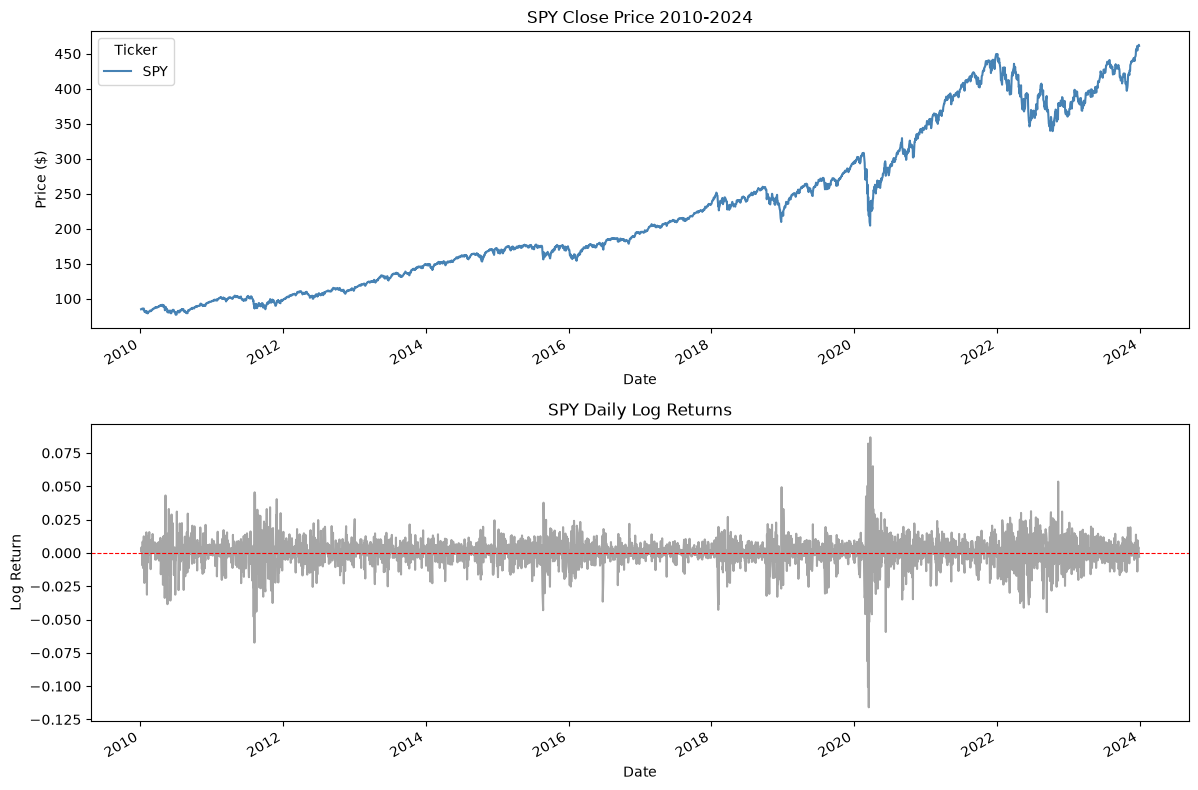

In [2]:
# Plot the price series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

df['Close'].plot(ax=ax1, title='SPY Close Price 2010-2024', color='steelblue')
ax1.set_ylabel('Price ($)')

df['log_returns'].plot(ax=ax2, title='SPY Daily Log Returns', color='grey', alpha=0.7)
ax2.set_ylabel('Log Return')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

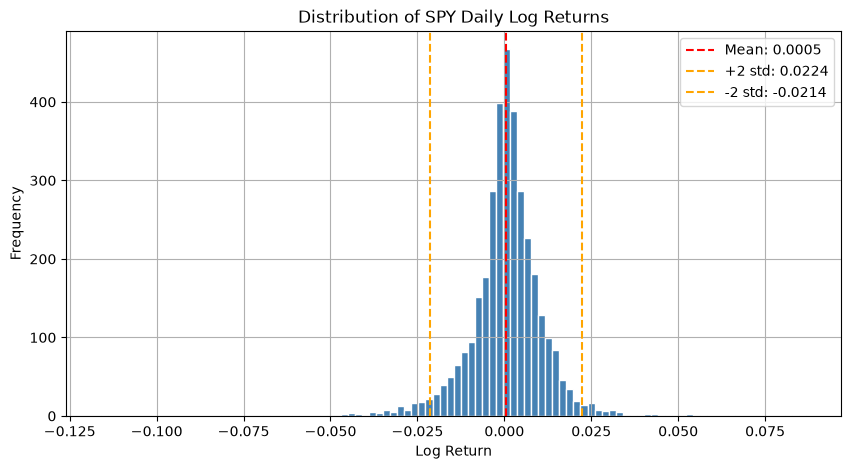

Mean daily return: 0.0005
Daily volatility: 0.0109
Annualised volatility: 0.1738
Skewness: -0.7178
Kurtosis: 11.5114


In [3]:
# Distribution of returns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
df['log_returns'].hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of SPY Daily Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')

# Add mean and std lines
mean = df['log_returns'].mean()
std = df['log_returns'].std()
ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.4f}')
ax.axvline(mean + 2*std, color='orange', linestyle='--', label=f'+2 std: {mean+2*std:.4f}')
ax.axvline(mean - 2*std, color='orange', linestyle='--', label=f'-2 std: {mean-2*std:.4f}')
ax.legend()
plt.show()

print(f"Mean daily return: {mean:.4f}")
print(f"Daily volatility: {std:.4f}")
print(f"Annualised volatility: {std * np.sqrt(252):.4f}")
print(f"Skewness: {df['log_returns'].skew():.4f}")
print(f"Kurtosis: {df['log_returns'].kurtosis():.4f}")

### Comments: ###

1. Price (top-plot): long upward trend from $\$ 90$ in 2010 to  $\$ 450$ in 2024 - SPY is a strongly trending asset over this period. A momentum/trend-following strategy has a natural tailwind on this asset, while a pure mean reversion strategy on price levels would have been disastrous. The sharp drop in 2020 was due to the COVID crash.
2. Returns Chart: clustering of volatility is very evident - calm periods before explosive periods (called volatility clustering - a very well established fact in financial data). A very large spike in 2020 - a strategy that survives 2020 is significantly more robust than one that doesn't.
3. Distribution statistics:
   - Mean daily return: 0.0005 (roughly 12.6% annualised — consistent with S&P 500 long run returns)
   - Annualised volatility: 17.38% — typical for the S&P 500
   - Skewness: -0.7178 — negative skew means large negative returns happen more often than large positive returns of the same magnitude.       This is the classic equity market property — markets fall faster than they rise
   Kurtosis: 11.51 — this is the most important number. A normal distribution has kurtosis of 3. Value of 11.51 means the distribution    has extremely fat tails — large moves happen far more often than a normal distribution would predict. Therefore, financial returns are very emphatically NOT normally distributed. Any strategy evaluation that assumes normality is understating tail risk. As a result, we should not use Sharpe Ratio but instead Sortino ratio - treats downside volatility separately rather than assuming symmetry. 

## Asset Selection and Statistical Analysis: Testing for Mean-reversion ##

In [4]:
from src.features import add_all_features, adf_test, hurst_exponent

# Add features
df_features = add_all_features(df)
print(f"Shape after adding features: {df_features.shape}")
print(df_features[['Close', 'sma_20', 'sma_50', 
                     'momentum_20', 'volatility_20']].tail())

Shape after adding features: (3472, 10)
Price            Close      sma_20      sma_50 momentum_20 volatility_20
Ticker             SPY                                                  
Date                                                                    
2023-12-22  459.779907  448.440353  431.322427    0.043558      0.005950
2023-12-26  461.721344  449.556927  432.213398    0.049574      0.005890
2023-12-27  462.556183  450.693492  433.033280    0.050391      0.005882
2023-12-28  462.730896  451.854262  433.857043    0.051473      0.005856
2023-12-29  461.391296  452.861522  434.766356    0.044644      0.005971


In [5]:
# Test 1: Is the SPY price series mean-reverting?
adf_price = adf_test(df_features['Close'], name='SPY Price')

# Test 2: Are the log returns mean-reverting?
adf_returns = adf_test(df_features['log_returns'], name='SPY Log Returns')

# Test 3: Hurst exponent on price
h_price = hurst_exponent(df_features['Close'])

# Test 4: Hurst exponent on returns  
h_returns = hurst_exponent(df_features['log_returns'])


ADF Test — SPY Price
  Test statistic : 0.6301
  p-value        : 0.9883
  Mean-reverting : False

ADF Test — SPY Log Returns
  Test statistic : -12.7941
  p-value        : 0.0
  Mean-reverting : True

Hurst Exponent: 0.4076
  Interpretation: Mean reverting

Hurst Exponent: -0.0011
  Interpretation: Mean reverting


### Comments: ###
The ADF test on the price series yielded p = 0.99, confirming the price is non-stationary and not suitable for mean reversion strategies. The Hurst exponent of 0.41 on the price series confirms mild but insufficient mean reversion. Based on this analysis, a momentum-based moving average crossover strategy was selected as statistically appropriate for this asset.

#### Justification: ####
SPY price is not mean-reverting enough to profitably trade mean reversion strategies on directly. The moving average crossover momentum strategy you're building is therefore the appropriate choice for this asset — you're following the trend rather than betting against it, which is consistent with what the data actually shows.

Therefore, a moving average crossover momentum strategy is the appropraite choice for this asset - following the trend rather than betting against it. 


*Note: I am using the workflow described by Ernest Chan's "Algorithmic Trading" book - test the asset first, then choose the strategy based on evidence.*


Signal Distribution:
  Long  (+1): 2462 days (70.9%)
  Flat   (0): 0 days (0.0%)
  Short (-1): 1009 days (29.1%)
  Total     : 3471 days


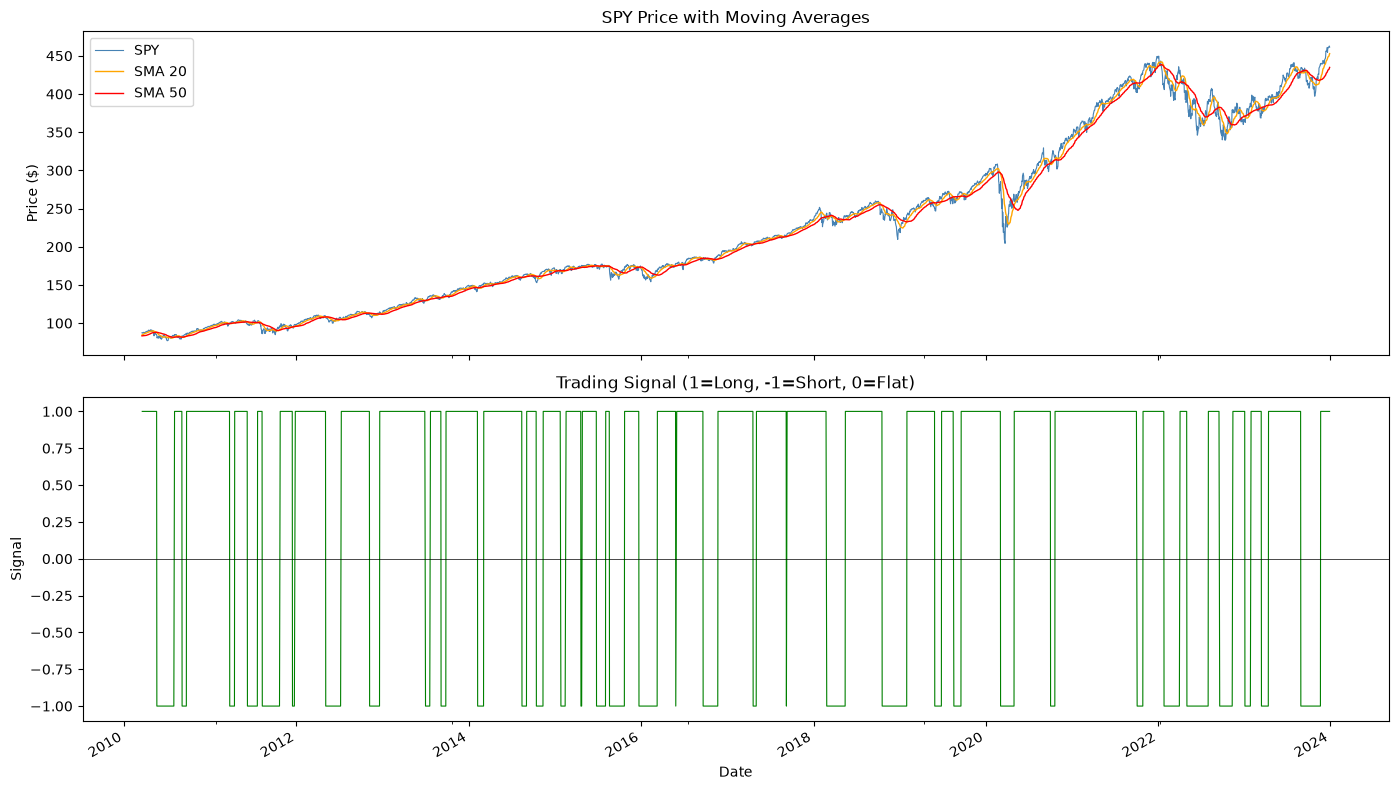

In [6]:
from src.signals import ma_crossover_signal, signal_summary
from src.features import add_all_features

# Generate signals
df_features = add_all_features(df)
signal = ma_crossover_signal(df_features, fast=20, slow=50)

# Check signal distribution
signal_summary(signal)

# Plot price with signals overlaid
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price with moving averages
df_features['Close'].plot(ax=ax1, color='steelblue', 
                           linewidth=0.8, label='SPY Price')
df_features['sma_20'].plot(ax=ax1, color='orange', 
                            linewidth=1, label='SMA 20')
df_features['sma_50'].plot(ax=ax1, color='red', 
                            linewidth=1, label='SMA 50')
ax1.set_title('SPY Price with Moving Averages')
ax1.set_ylabel('Price ($)')
ax1.legend()

# Signal over time
signal.plot(ax=ax2, color='green', linewidth=0.8)
ax2.set_title('Trading Signal (1=Long, -1=Short, 0=Flat)')
ax2.set_ylabel('Signal')
ax2.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

### Commments: ###

1. __Signal Distribution - 70.9% Long and 29.1% Short__
   This makes sense given what we already know about SPY. It's been in a generally upward trend from 2010-2024, so a momentum strategy naturally spends more time long than it does short
   
   